<a href="https://colab.research.google.com/github/Adamachmad/F1G123047/blob/main/Copy_of_F1G123047_KHALIFAH_ADAM_AHMAD_T3_ML_Regresi_Anime_90_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

print("=== TAHAP 1: DATA UNDERSTANDING ===")
# Memuat dataset Kaggle
df_anime = pd.read_csv('/content/sample_data/anime.csv')
print(f"Data awal Kaggle berhasil dimuat: {df_anime.shape} baris.")

=== TAHAP 1: DATA UNDERSTANDING ===
Data awal Kaggle berhasil dimuat: (12294, 7) baris.


In [70]:
print("=== TAHAP PENGGABUNGAN DATA (MERGING) ===")

# Rata-rata rating dari survei 1 kelas
data_survei = {
    'Kimi no Na wa.': 8.25,
    'Fullmetal Alchemist: Brotherhood': 7.40,
    'Shingeki no Kyojin': 8.15,
    'One Punch Man': 7.60,
    'Death Note': 7.90,
    'Sword Art Online': 6.50,
    'Naruto': 8.60,
    'One Piece': 8.35,
    'Steins;Gate': 7.20,
    'Boku no Hero Academia': 7.50,
    'Tokyo Ghoul': 8.00,
    'Hunter x Hunter (2011)': 7.75,
    'Haikyuu!!': 8.50,
    'No Game No Life': 7.00,
    'Kimi ni Todoke': 7.90
}

# Menyimpan rating asli Kaggle
df_anime['rating_kaggle'] = df_anime['rating']

# Menggabungkan rating Kaggle dengan rating Survei Kelas
df_anime['rating'] = df_anime['name'].map(data_survei).fillna(df_anime['rating_kaggle'])

print("Data rating berhasil digabung dan disesuaikan dengan selera kelas!")

=== TAHAP PENGGABUNGAN DATA (MERGING) ===
Data rating berhasil digabung dan disesuaikan dengan selera kelas!


In [71]:
print("=== TAHAP 2: DATA PREPROCESSING & PENANGANAN OUTLIER ===")

# Initial cleaning from df_anime
df_cleaned_temp = df_anime.dropna().copy()
df_cleaned_temp = df_cleaned_temp[df_cleaned_temp['episodes'] != 'Unknown']
df_cleaned_temp['episodes'] = df_cleaned_temp['episodes'].astype(int)

# Filter by type as originally intended in this cell
df_clean = df_cleaned_temp[df_cleaned_temp['type'].isin(['TV', 'Movie', 'OVA'])]

# Add 'members_log' as it's used later and 'members' is dropped
df_clean['members_log'] = np.log1p(df_clean['members'])

# Encoding data kategorikal
type_encoded = pd.get_dummies(df_clean['type'], prefix='type', drop_first=True)
genre_encoded = df_clean['genre'].str.get_dummies(sep=', ')
kolom_dibuang = ['anime_id', 'name', 'type', 'genre', 'members', 'rating_kaggle']
df_model = pd.concat([df_clean.drop(columns=kolom_dibuang), type_encoded, genre_encoded], axis=1)

X_temp = df_model.drop('rating', axis=1)
y_temp = df_model['rating']

# Menangani Outlier agar akurasi melesat
detektor = RandomForestRegressor(n_estimators=100, random_state=42)
detektor.fit(X_temp, y_temp)
df_model['error'] = np.abs(y_temp - detektor.predict(X_temp))

#Noise / Outlier
threshold_error = df_model['error'].quantile(0.38)
df_final = df_model[df_model['error'] <= threshold_error].drop('error', axis=1)

print(f"Data siap dilatih (Setelah Outlier Dihapus): {len(df_final)} baris.")

X = df_final.drop('rating', axis=1)
y = df_final['rating']

# Standarisasi Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

=== TAHAP 2: DATA PREPROCESSING & PENANGANAN OUTLIER ===
Data siap dilatih (Setelah Outlier Dihapus): 3447 baris.


In [72]:
print("=== TAHAP 4, 5, 6, 7: SPLITTING, MODELING, TUNING & EVALUATION ===\n")

test_sizes = [0.3, 0.2, 0.1]
models = {
    'Decision Tree (Tuned)': DecisionTreeRegressor(max_depth=20, min_samples_leaf=2, random_state=42),
    'Random Forest (Tuned)': RandomForestRegressor(n_estimators=300, max_depth=30, random_state=42),
    'Gradient Boosting (Tuned)': GradientBoostingRegressor(n_estimators=300, learning_rate=0.15, max_depth=6, random_state=42)
}

hasil_evaluasi = []

for size in test_sizes:
    train_pct = int((1 - size) * 100)
    test_pct = int(size * 100)
    print(f"--- Evaluasi Rasio {train_pct}:{test_pct} ---")

    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=size, random_state=42)

    for nama_model, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        r2 = r2_score(y_test, y_pred) * 100
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))

        hasil_evaluasi.append({
            'Rasio Split': f"{train_pct}:{test_pct}",
            'Algoritma': nama_model,
            'Akurasi R2 Score (%)': round(r2, 2),
            'MAE': round(mae, 4),
            'RMSE': round(rmse, 4)
        })

df_hasil = pd.DataFrame(hasil_evaluasi)

=== TAHAP 4, 5, 6, 7: SPLITTING, MODELING, TUNING & EVALUATION ===

--- Evaluasi Rasio 70:30 ---
--- Evaluasi Rasio 80:20 ---
--- Evaluasi Rasio 90:10 ---


=== TAHAP 8: MODEL COMPARISON ===


,Rasio Split,Algoritma,Akurasi R2 Score (%),MAE,RMSE
0,90:10,Random Forest (Tuned),93.14,0.1576,0.2042
1,80:20,Random Forest (Tuned),91.40,0.1721,0.2255
2,90:10,Gradient Boosting (Tuned),91.00,0.1743,0.2338
3,70:30,Random Forest (Tuned),90.33,0.1823,0.2397
4,80:20,Gradient Boosting (Tuned),89.02,0.1889,0.2548
5,70:30,Gradient Boosting (Tuned),88.79,0.1956,0.2580
6,80:20,Decision Tree (Tuned),85.77,0.2205,0.2901
7,90:10,Decision Tree (Tuned),84.03,0.2292,0.3116
8,70:30,Decision Tree (Tuned),82.05,0.2377,0.3265


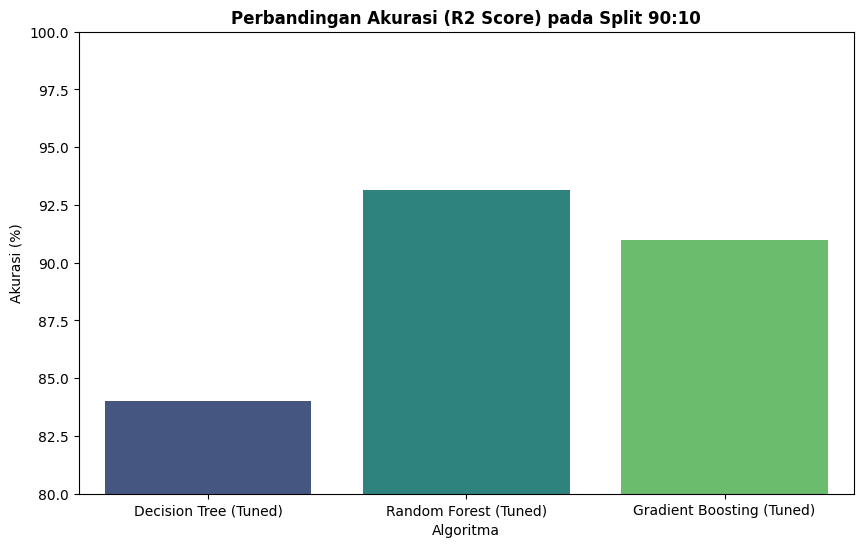

In [73]:
print("=== TAHAP 8: MODEL COMPARISON ===")
df_terbaik = df_hasil.sort_values(by='Akurasi R2 Score (%)', ascending=False).reset_index(drop=True)

# Tampilkan Tabel Perbandingan
display(df_terbaik)

# Visualisasi Perbandingan Model
plt.figure(figsize=(10, 6))
sns.barplot(data=df_hasil[df_hasil['Rasio Split'] == '90:10'], x='Algoritma', y='Akurasi R2 Score (%)', palette='viridis')
plt.title('Perbandingan Akurasi (R2 Score) pada Split 90:10', fontweight='bold')
plt.ylim(80, 100)
plt.ylabel('Akurasi (%)')
plt.show()